In [12]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.train as tr
import src.evaluation as ev

In [ ]:
train_merged = pd.read_csv("../outputs/train_fe.csv")
train_merged["date"] = pd.to_datetime(train_merged["date"])


In [ ]:
split_date = train_merged['date'].quantile(0.8)
train_part = train_merged[train_merged['date'] <  split_date].copy()
test_part  = train_merged[train_merged['date'] >= split_date].copy()


In [14]:
categorical_cols = ['store_nbr', 'family', 'city', 'state', 'type']

numerical_cols = [
    'onpromotion', 'dcoilwtico', 'cluster',
    'year', 'month', 'day', 'dayofweek',
    'is_weekend', 'is_month_start', 'is_month_end',
    'holiday_national_binary',
    'is_black_friday', 'is_cyber_monday', 'is_mothers_day',
    'is_earthquake', 'is_world_cup',
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
    'rolling_std_7', 'promo_last_7', 'oil_change'
]

target_col = 'sales'


In [15]:
X_train = train_part[categorical_cols + numerical_cols].copy()
y_train = train_part[target_col].copy()

X_test  = test_part[categorical_cols + numerical_cols].copy()
y_test  = test_part[target_col].copy()

In [16]:
X_train[numerical_cols] = X_train[numerical_cols].replace([np.inf, -np.inf], 0)
X_test[numerical_cols] = X_test[numerical_cols].replace([np.inf, -np.inf], 0)

X_train[numerical_cols] = X_train[numerical_cols].fillna(0)
X_test[numerical_cols] = X_test[numerical_cols].fillna(0)

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
X_train_dense = X_train_processed.toarray()
X_test_dense = X_test_processed.toarray()

In [18]:
baseline_model, history_baseline = tr.train_baseline_model(
    X_train_dense,
    y_train,
    learning_rate=0.0005,
    epochs=20,
    batch_size=512,
    validation_split=0.1,
    patience=3
)

Epoch 1/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 197283.4062 - mae: 104.8694 - val_loss: 55977.2383 - val_mae: 85.1388
Epoch 2/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 89234.2891 - mae: 67.4372 - val_loss: 54649.7422 - val_mae: 93.7864
Epoch 3/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 83401.1172 - mae: 64.5205 - val_loss: 61770.1719 - val_mae: 105.2490
Epoch 4/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 80607.8125 - mae: 63.3355 - val_loss: 53856.1758 - val_mae: 96.6485
Epoch 5/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 78883.6875 - mae: 62.4454 - val_loss: 54269.7578 - val_mae: 98.3307
Epoch 6/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 77657.8594 - mae: 61.9372 - val_loss: 54140.6992 - val_mae: 98.3527
Epoch 7/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 76433.5234 - mae: 61.8478 - val_loss: 53780.8711 - val_mae: 96.9946
Epoch 8/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 75343.2734 - mae: 61.91

In [19]:
baseline_model = keras.Sequential([
    layers.Input(shape=(X_train_dense.shape[1],)),
    layers.Dense(64, activation = "relu"), 
    layers.Dense(32, activation = "relu"), 
    layers.Dense(1)
])

In [20]:
baseline_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.0005), 
    loss= "mse",
    metrics = ["mae"]
)

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,097 (47.25 KB)

 Trainable params: 12,097 (47.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience= 3,
    restore_best_weights = True
)

In [19]:
history_baseline= baseline_model.fit(
    X_train_dense,
    y_train,
    validation_split= 0.1,
    epochs = 20,
    batch_size= 512,
    callbacks = [early_stop],
    verbose= 1
)

Epoch 1/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 183453.7969 - mae: 102.7270 - val_loss: 56555.1016 - val_mae: 83.9661
Epoch 2/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 88549.3750 - mae: 68.1326 - val_loss: 53820.5352 - val_mae: 92.1725
Epoch 3/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 82787.0547 - mae: 65.0647 - val_loss: 53580.6289 - val_mae: 95.0709
Epoch 4/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 46s 11ms/step - loss: 79880.0312 - mae: 63.2327 - val_loss: 58170.5391 - val_mae: 100.6150
Epoch 5/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - loss: 78183.5000 - mae: 62.3117 - val_loss: 55592.8320 - val_mae: 105.7914
Epoch 6/20
4220/4220 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - loss: 76786.0312 - mae: 61.7669 - val_loss: 54493.7734 - val_mae: 105.1446


In [22]:
baseline_preds = baseline_model.predict(X_test_dense).flatten()
print(baseline_preds[:10]) 

baseline_rmse = root_mean_squared_error(y_test, baseline_preds)
baseline_mae = mean_absolute_error(y_test, baseline_preds)
print("Baseline RMSE: ", baseline_rmse)
print("Baseline MAE: ", baseline_mae)

18767/18767 ━━━━━━━━━━━━━━━━━━━━ 14s 745us/step
[  8.976568  22.335848  20.330105  15.308473  15.099738 -35.24206
 -65.695625   9.905375  20.143099  23.882925]
Baseline RMSE:  345.0988168201859
Baseline MAE:  91.62998707373698


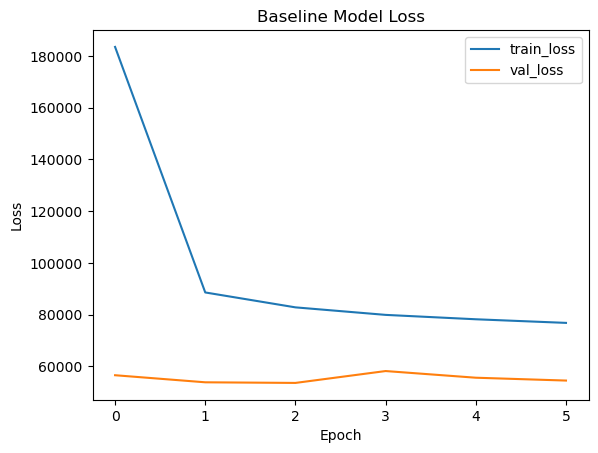

In [23]:
plt.figure()
plt.plot(history_baseline.history["loss"], label="train_loss")
plt.plot(history_baseline.history["val_loss"], label="val_loss")
plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [24]:
import joblib
joblib.dump(preprocessor, "../outputs/preprocessor.pkl")

baseline_model.save("../outputs/baseline_model.h5")

pd.DataFrame({
    "y_true": y_test,
    "y_pred": baseline_preds.flatten()
}).to_csv("../outputs/baseline_predictions.csv", index=False)

pd.DataFrame([{
    "rmse": baseline_rmse,
    "mae": baseline_mae
}]).to_csv("../outputs/baseline_metrics.csv", index=False)